# 01. Data preparation

**Goal:** see the nnU-Net dataset format, look at the data, and understand the most important step for fine-tuning: matching the pretrained checkpoint's preprocessing.

The sample is a synthetic CT phantom (no patient data; see `DATA_PROVENANCE.md`).

In [1]:
# bootstrap: make course_utils + scripts importable from any working directory,
# use the inline backend so figures render, and regenerate the phantom if missing.
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    return start


REPO = _find_repo_root(Path.cwd())
for _p in (str(REPO), str(REPO / "scripts")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA = REPO / "assets" / "data" / "Dataset999_Phantom"
PRE = REPO / "assets" / "precomputed"

if not (DATA / "imagesTr" / "PHANTOM_001_0000.nii.gz").exists():
    import generate_phantom
    generate_phantom.generate(REPO / "assets" / "data")

print("repo root:", REPO.name)


repo root: internal-mini-course


## nnU-Net dataset layout

```
Dataset999_Phantom/
  imagesTr/PHANTOM_001_0000.nii.gz   # channel 0 (the '_0000' suffix marks the modality)
  labelsTr/PHANTOM_001.nii.gz        # label map, same case id, no channel suffix
  dataset.json                       # declares channel_names and labels
```

In [2]:
import json
meta = json.loads((DATA / 'dataset.json').read_text())
print(json.dumps(meta, indent=2))

{
  "channel_names": {
    "0": "CT"
  },
  "labels": {
    "background": 0,
    "lesion": 1
  },
  "numTraining": 1,
  "file_ending": ".nii.gz",
  "description": "Synthetic CT phantom (no patient data). See DATA_PROVENANCE.md."
}


## Load the volume and look at it

Load the CT and its label, check the shape and intensity range, and list the label values. Then view a few axial slices so you can see the phantom and its lesion.

In [3]:
import nibabel as nib
ct = np.asarray(nib.load(str(DATA / 'imagesTr' / 'PHANTOM_001_0000.nii.gz')).dataobj, dtype=np.float32)
gt = np.rint(np.asarray(nib.load(str(DATA / 'labelsTr' / 'PHANTOM_001.nii.gz')).dataobj)).astype(int)
print('CT shape:', ct.shape)
print('intensity range:', (round(float(ct.min())), round(float(ct.max()))))
print('label values (np.unique):', np.unique(gt))

CT shape: (64, 64, 32)
intensity range: (-1000, 147)
label values (np.unique): [0 1]


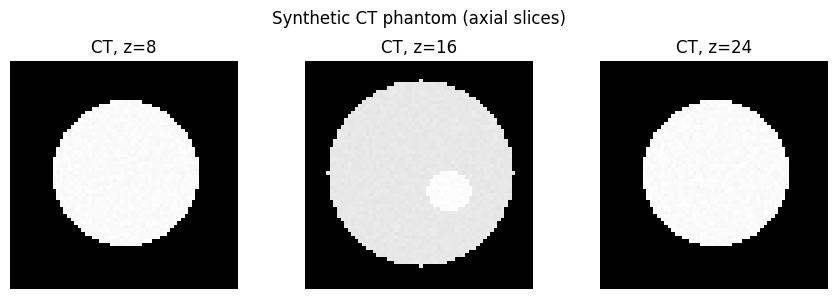

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, z in zip(axes, [8, 16, 24]):
    ax.imshow(ct[:, :, z].T, cmap='gray', origin='lower')
    ax.set_title(f'CT, z={z}')
    ax.axis('off')
fig.suptitle('Synthetic CT phantom (axial slices)')
fig.tight_layout()
plt.show()

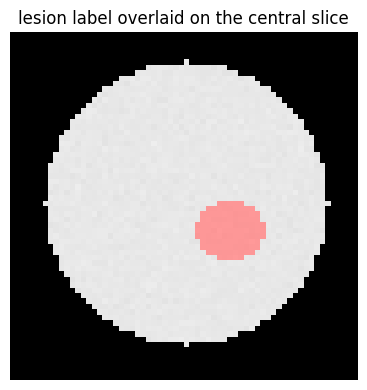

In [5]:
from course_utils.viz import overlay_mask_on_slice
ax = overlay_mask_on_slice(ct, gt)
ax.set_title('lesion label overlaid on the central slice')
ax.figure.tight_layout()
plt.show()

## Match the pretraining preprocessing

The checkpoint was trained on volumes resampled to 1 mm isotropic and Z-score normalized. Fine-tuning data has to be preprocessed the same way, or the pretrained features do not line up with the inputs. This is a property of the chosen checkpoint, not a default nnU-Net rule: nnU-Net normally derives spacing and normalization from your own dataset.

In practice you copy the checkpoint's `plans.json` onto your dataset and preprocess with it (read-only here; needs the real toolchain and the checkpoint):

```bash
nnUNetv2_move_plans_between_datasets -s <PRETRAIN_ID> -t 999 \
    -sp nnUNetResEncUNetLPlans -tp nnUNetResEncUNetLPlans
nnUNetv2_preprocess -d 999 -plans_name nnUNetResEncUNetLPlans -c 3d_fullres
```

In [6]:
# The Z-score step the pretraining used, shown here on the phantom body (ignoring air).
body = ct > -500
z = ct.copy()
z[body] = (ct[body] - ct[body].mean()) / (ct[body].std() + 1e-8)
print('after Z-score on the body: mean=%.3f std=%.3f' % (z[body].mean(), z[body].std()))

after Z-score on the body: mean=0.000 std=1.000


## Recap
1. nnU-Net uses a fixed `imagesTr / labelsTr / dataset.json` layout with a `_0000` channel suffix.
2. Always check spacing, intensities, and `np.unique(label)`.
3. Match the checkpoint's preprocessing (1 mm isotropic, Z-score) by moving its plans onto your data.